# Robust likelihoods: Student-t versus the multivariate normal

A few gross outliers make a Gaussian fit confidently wrong.  The likelihood
*functional* is a drop-in choice in `rxmc`: keep the covariance, swap the
multivariate normal for a multivariate Student-t with a sampled tail
parameter, and the fit widens instead of breaking.  Then two ways to say
"the errors are larger than stated": a global scale on the reported errors,
and an unrecognised, fully correlated component per experimental technique.

Recipes: 9, 34

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import rxmc as rx
from rxmc import terms as T

## A clean signal with a few gross outliers

Twenty-five points of a line with 5 % noise, and three points pushed up by
ten times their error: a background the experiment did not subtract.

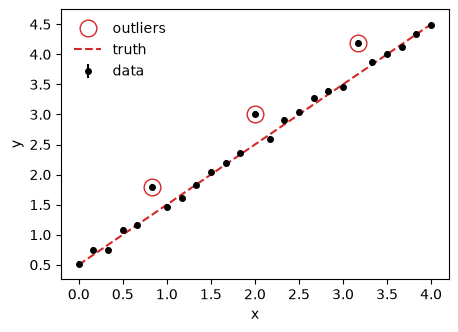

In [2]:
rng = np.random.default_rng(21)
m_true, b_true = 1.0, 0.5
x = np.linspace(0.0, 4.0, 25)
noise = 0.05
y = m_true * x + b_true + rng.normal(0.0, noise, x.size)
outliers = np.array([5, 12, 19])
y[outliers] += np.array([10.0, 12.0, 9.0]) * noise
data = rx.Dataset(x, y, np.full(x.size, noise), label="with outliers")

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=4, color="k", label="data")
ax.plot(x[outliers], y[outliers], "o", ms=12, mfc="none", color="C3", label="outliers")
ax.plot(x, m_true * x + b_true, "--", color="C3", label="truth")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

## The same constraint, two likelihood functionals

`rx.StudentT(nu)` applies one radial tail to the whole stacked residual of
the constraint; `nu` is an ordinary parameter with its bounds and prior on
the `Parameter`, so it is one more column of the chain.

In [3]:
m = rx.Parameter("m", prior=stats.norm(1.0, 1.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.0, 1.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp = rx.Comparison(data, line)
nu = rx.Parameter("nu", bounds=(1.0, 100.0), latex=r"\nu")  # uniform on its bounds

p_gauss = rx.Problem([rx.Constraint([comp])])
p_t = rx.Problem([rx.Constraint([comp], likelihood=rx.StudentT(nu))])
print("Gaussian :", p_gauss.names)
print("Student-t:", p_t.names)


def fit(problem, seed, n_walkers=24, n_steps=2000):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


s_gauss, s_t = fit(p_gauss, 1), fit(p_t, 2)

Gaussian : ['m', 'b']
Student-t: ['m', 'b', 'nu']


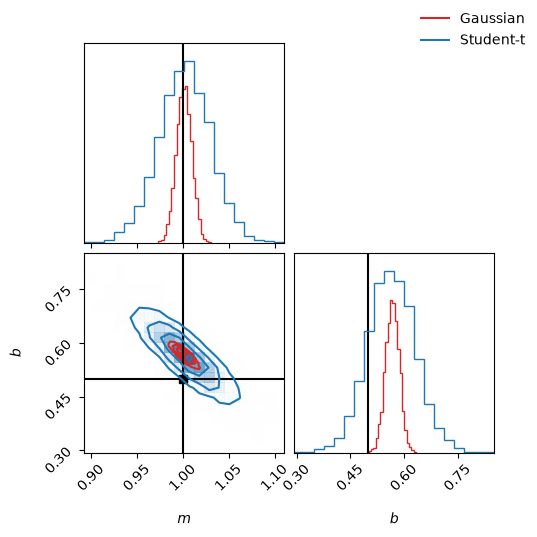

Gaussian   m = 1.001 +/- 0.008, b = 0.567 +/- 0.019; truth at 3.5 sigma
Student-t  m = 1.002 +/- 0.029, b = 0.566 +/- 0.067; truth at 1.0 sigma


In [4]:
fig = corner.corner(
    s_gauss,
    color="C3",
    labels=["$m$", "$b$"],
    truths=[m_true, b_true],
    truth_color="k",
    plot_datapoints=False,
)
corner.corner(
    s_t[:, p_t.columns(line.params)], fig=fig, color="C0", plot_datapoints=False
)
fig.legend(
    handles=[
        plt.Line2D([], [], color="C3", label="Gaussian"),
        plt.Line2D([], [], color="C0", label="Student-t"),
    ],
    loc="upper right",
    frameon=False,
)
plt.show()
for name, p, s in (("Gaussian", p_gauss, s_gauss), ("Student-t", p_t, s_t)):
    cols = p.columns(line.params)
    pull = (s[:, cols].mean(0) - [m_true, b_true]) / s[:, cols].std(0)
    print(
        f"{name:10s} m = {s[:, cols[0]].mean():.3f} +/- {s[:, cols[0]].std():.3f}, b = {s[:, cols[1]].mean():.3f} +/- {s[:, cols[1]].std():.3f}; truth at {np.abs(pull).max():.1f} sigma"
    )

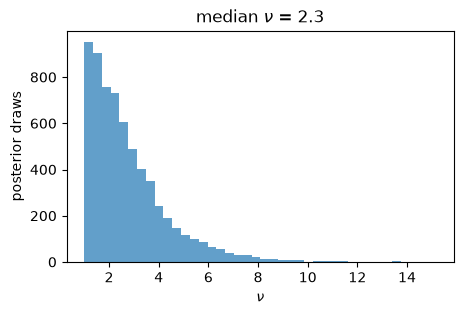

In [5]:
nu_col = p_t.columns(nu)
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(s_t[:, nu_col], bins=40, color="C0", alpha=0.7)
ax.set(
    xlabel=r"$\nu$",
    ylabel="posterior draws",
    title=rf"median $\nu$ = {np.median(s_t[:, nu_col]):.1f}",
)
plt.show()

The Gaussian puts the truth several σ away: three points at ten σ dominate
a quadratic penalty.  The Student-t reaches a small `ν`, its tails absorb
the outliers, and the truth is covered.  Note what it does *not* do: it does
not reject the outliers, it widens.  Per-point rejection would need per-point
machinery, such as masking the suspects (recipe 11).

### χ² is the same for both

The covariance is shared; only the functional of the Mahalanobis distance
differs.  `problem.chi2` is that distance, and `rx.Chi2()` is the functional
that drops the log-determinant for a pure χ² objective.

In [6]:
theta = np.array([m_true, b_true])
print(
    f"chi2 at the truth: Gaussian {p_gauss.chi2(theta):.2f}, Student-t {p_t.chi2(np.append(theta, 5.0)):.2f}"
)

chi2 at the truth: Gaussian 322.62, Student-t 322.62


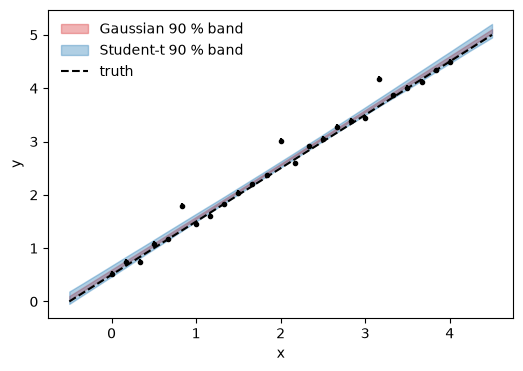

In [7]:
x_fine = np.linspace(-0.5, 4.5, 60)
on_fine = line.bind(x_fine, {})
fig, ax = plt.subplots(figsize=(6, 4))
for name, p, s, color in (
    ("Gaussian", p_gauss, s_gauss, "C3"),
    ("Student-t", p_t, s_t, "C0"),
):
    lo, hi = rx.predictive.predictive_band(
        [on_fine(*r[p.columns(line.params)]) for r in s[::10]], levels=(5, 95)
    )
    ax.fill_between(x_fine, lo, hi, color=color, alpha=0.35, label=f"{name} 90 % band")
ax.errorbar(data.x, data.y, data.y_err, fmt="o", ms=3, color="k")
ax.plot(x_fine, m_true * x_fine + b_true, "--", color="k", label="truth")
ax.set(xlabel="x", ylabel="y")
ax.legend(frameon=False)
plt.show()

## Errors larger than stated (recipe 34)

Two more honest options when the data scatter more than their errors say.

**A global scale** on the reported errors: a `diag` term that closes over
the comparison's errors, with `statistical=False` so it *is* the diagonal.
Under the Gaussian the scale has to grow until every point's error covers
the outliers, and it is poorly determined; under the Student-t the tail
shares the work, so the scale is smaller and better determined.  Either way
a global scale inflates every point equally, which is why it is judged poor
evaluation practice next to a targeted term.

In [8]:
log_s = rx.Parameter("log_s", prior=stats.norm(0.0, 0.5), latex=r"\log s")
scaled = rx.Term(lambda c, ls: np.exp(ls) * comp.y_err, (log_s,), kind="diag", on=comp)
p_scale_gauss = rx.Problem([rx.Constraint([comp], terms=[scaled], statistical=False)])
p_scale_t = rx.Problem(
    [
        rx.Constraint(
            [comp], terms=[scaled], statistical=False, likelihood=rx.StudentT(nu)
        )
    ]
)
for name, p, seed in (("Gaussian", p_scale_gauss, 3), ("Student-t", p_scale_t, 4)):
    s = fit(p, seed)
    lo, med, hi = np.percentile(np.exp(s[:, p.columns(log_s)]), [16, 50, 84])
    print(f"{name:10s} error scale s = {med:.2f}  (68 % interval {lo:.2f} to {hi:.2f})")

Gaussian   error scale s = 3.22  (68 % interval 2.83 to 3.68)


Student-t  error scale s = 2.91  (68 % interval 2.18 to 3.48)


**An unrecognised source of uncertainty** per technique: suppose the
outliers are not three random points but a second technique whose whole
dataset carries an unknown offset.  A sampled `T.offset` on that technique's
comparisons is a fully correlated component *inside* the covariance, which
shifts the evaluated mean as well as its width.  A global scale cannot do
that.

as stated        m = 0.991 +/- 0.008, b = 0.637 +/- 0.020


global scale     m = 0.989 +/- 0.036, b = 0.654 +/- 0.232


USU offset on B  m = 0.991 +/- 0.008, b = 0.526 +/- 0.022


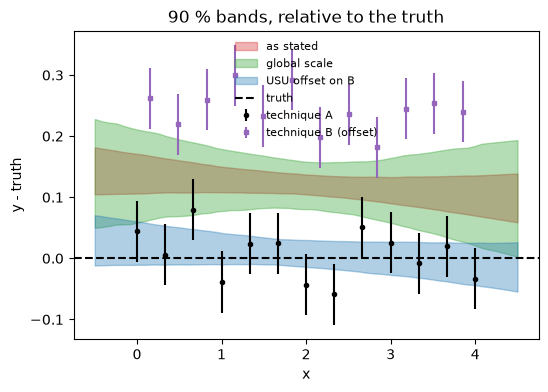

In [9]:
x_a, x_b = np.linspace(0.0, 4.0, 13), np.linspace(0.15, 3.85, 12)
y_a = m_true * x_a + b_true + rng.normal(0.0, noise, x_a.size)
y_b = (
    m_true * x_b + b_true + 0.25 + rng.normal(0.0, noise, x_b.size)
)  # a 0.25 offset nobody reported
d_a = rx.Dataset(
    x_a, y_a, np.full(x_a.size, noise), label="technique A", meta={"technique": "A"}
)
d_b = rx.Dataset(
    x_b, y_b, np.full(x_b.size, noise), label="technique B", meta={"technique": "B"}
)
comps = [rx.Comparison(d_a, line), rx.Comparison(d_b, line)]
log_usu = rx.Parameter(
    "log_usu_B", prior=stats.norm(np.log(0.2), 1.0), latex=r"\log\delta_B"
)
usu = T.offset(log_usu, on=[c for c in comps if c.data.meta["technique"] == "B"])
scaled_ab = [
    rx.Term(
        lambda c, ls, comp=comp: np.exp(ls) * comp.y_err, (log_s,), kind="diag", on=comp
    )
    for comp in comps
]

problems = {
    "as stated": rx.Problem([rx.Constraint(comps)]),
    "global scale": rx.Problem(
        [rx.Constraint(comps, terms=scaled_ab, statistical=False)]
    ),
    "USU offset on B": rx.Problem([rx.Constraint(comps, terms=[usu])]),
}
truth_line = m_true * x_fine + b_true
fig, ax = plt.subplots(figsize=(6, 4))
for (name, p), color, seed in zip(problems.items(), ("C3", "C2", "C0"), (5, 6, 7)):
    s = fit(p, seed)
    cols = p.columns(line.params)
    print(
        f"{name:16s} m = {s[:, cols[0]].mean():.3f} +/- {s[:, cols[0]].std():.3f}, b = {s[:, cols[1]].mean():.3f} +/- {s[:, cols[1]].std():.3f}"
    )
    lo, hi = rx.predictive.predictive_band(
        [on_fine(*r[cols]) for r in s[::10]], levels=(5, 95)
    )
    ax.fill_between(
        x_fine, lo - truth_line, hi - truth_line, color=color, alpha=0.35, label=name
    )
ax.errorbar(
    d_a.x,
    d_a.y - (m_true * d_a.x + b_true),
    d_a.y_err,
    fmt="o",
    ms=3,
    color="k",
    label="technique A",
)
ax.errorbar(
    d_b.x,
    d_b.y - (m_true * d_b.x + b_true),
    d_b.y_err,
    fmt="s",
    ms=3,
    color="C4",
    label="technique B (offset)",
)
ax.axhline(0.0, ls="--", color="k", label="truth")
ax.set(xlabel="x", ylabel="y - truth", title="90 % bands, relative to the truth")
ax.legend(frameon=False, fontsize=8)
plt.show()

## Takeaways

- The likelihood functional is a drop-in; `ν` is an ordinary column.
- The multivariate t buys honesty, not outlier rejection: it widens.
- A global error scale inflates every point equally; under a heavy-tailed
  likelihood it stays modest.
- An unrecognised component belongs *in* the covariance, as a sampled
  correlated term on the technique it afflicts: it moves the mean, which is
  what a Birge-type rescaling after the fact cannot do.